In [28]:
import pandas as panda
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# Charger le dataset
df = panda.read_csv('games.csv')

# CORRECTION: Les colonnes du CSV sont décalées
# AppID contient les noms, Name contient les dates, Release date contient les plages
df = df.rename(columns={
    'AppID': 'Name_temp',
    'Name': 'Release date',
    'Release date': 'Estimated owners range'
})
df = df.rename(columns={'Name_temp': 'Name'})

# Vérification
print("Colonnes:", df.columns.tolist()[:6])
print("\nName:", df['Name'].iloc[0])
print("Release date:", df['Release date'].iloc[0])
print("Estimated owners range:", df['Estimated owners range'].iloc[0])
print("Price:", df['Price'].iloc[0])

Colonnes: ['Name', 'Release date', 'Estimated owners range', 'Estimated owners', 'Peak CCU', 'Required age']

Name: Black Dragon Mage Playtest
Release date: Aug 1, 2023
Estimated owners range: 0 - 0
Price: 0


In [29]:
print("=== Types de données ===")
print(df.dtypes)

print("\n=== Données manquantes ===")
print(df.isnull().sum())

print("\n=== Statistiques de base ===")
df[['Price', 'Positive', 'Negative', 'Metacritic score', 'Average playtime forever']].describe()

=== Types de données ===
Name                              str
Release date                      str
Estimated owners range            str
Estimated owners                int64
Peak CCU                        int64
Required age                  float64
Price                           int64
DiscountDLC count               int64
About the game                    str
Supported languages               str
Full audio languages              str
Reviews                           str
Header image                      str
Website                           str
Support url                       str
Support email                     str
Windows                          bool
Mac                              bool
Linux                            bool
Metacritic score                int64
Metacritic url                    str
User score                      int64
Positive                        int64
Negative                        int64
Score rank                    float64
Achievements             

,Price,Positive,Negative,Metacritic score,Average playtime forever
count,122611.000000,1.226110e+05,1.226110e+05,122611.000000,1.226110e+05
mean,18.353663,1.044986e+03,1.691974e+02,2.564941,2.080232e+02
std,28.858970,2.809173e+04,5.374645e+03,13.660559,1.121768e+04
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00
50%,0.000000,5.000000e+00,1.000000e+00,0.000000,0.000000e+00
75%,40.000000,3.700000e+01,1.000000e+01,0.000000,0.000000e+00
max,100.000000,7.642084e+06,1.173003e+06,97.000000,3.429544e+06


In [30]:
# On va seulement garder les jeux avec au moins 10 avis positifs, car les jeux avec 0 avis ne nous apprennent rien
df_clean = df[(df['Positive'] + df['Negative']) >= 10].copy()

#On crée une colonne pour voir le taux de satisfaction en %
df_clean['satisfaction'] = (df_clean['Positive'] / (df_clean['Positive'] + df_clean['Negative']) * 100).round(1)

print(f"Jeux avant nettoyage: {len(df)}")
print(f"Jeux après nettoyage: {len(df_clean)}")
print(f"Jeux supprimés: {len(df) - len(df_clean)}")

Jeux avant nettoyage: 122611
Jeux après nettoyage: 56655
Jeux supprimés: 65956


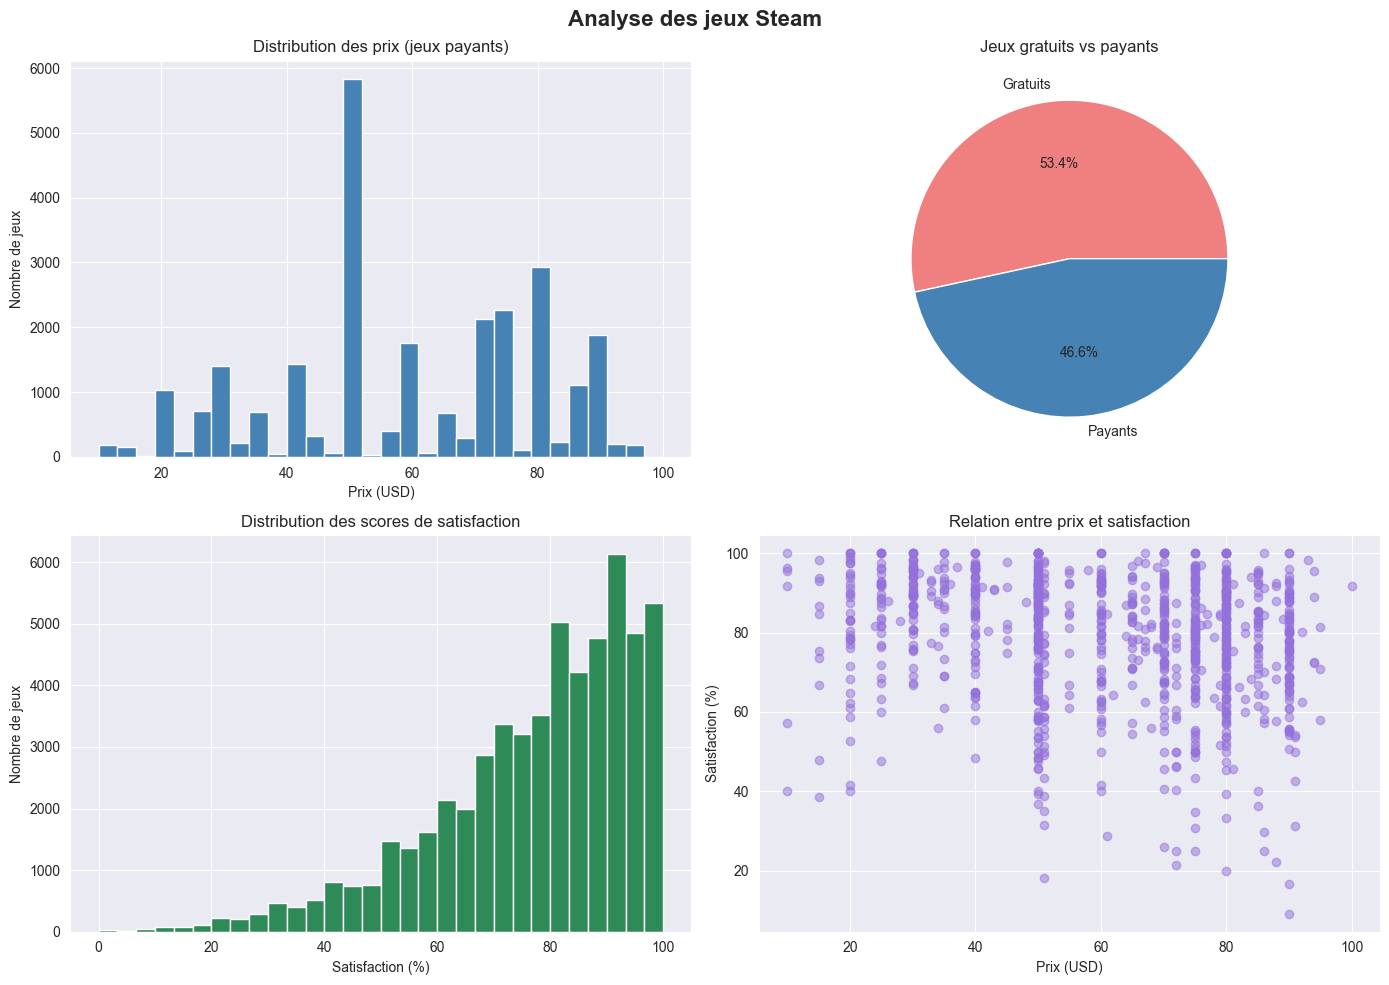

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

#Style des graphiques
sns.set_style("darkgrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Analyse des jeux Steam", fontsize=16, fontweight='bold')

#Graphue 1: Distribution des prix
axes[0, 0].hist(df_clean[df_clean['Price'] > 0]['Price'], bins=30, color='steelblue', edgecolor='white')
axes[0, 0].set_title("Distribution des prix (jeux payants)")
axes[0, 0].set_xlabel("Prix (USD)")
axes[0, 0].set_ylabel("Nombre de jeux")

#Graphique 2: Jeux gratuits vs payants
gratuit = (df_clean['Price'] == 0).sum()
payant = (df_clean['Price'] > 0).sum()
axes[0,1].pie([gratuit,payant], labels=['Gratuits', 'Payants'], autopct='%1.1f%%', colors=['lightcoral', 'steelblue'])
axes[0,1].set_title("Jeux gratuits vs payants")

#Graphique 3: Distribution des scores de satisfaction
axes[1,0].hist(df_clean['satisfaction'], bins=30, color='seagreen', edgecolor='white')
axes[1,0].set_title("Distribution des scores de satisfaction")
axes[1,0].set_xlabel("Satisfaction (%)")
axes[1,0].set_ylabel("Nombre de jeux")

#Graphique 4: Relation entre prix et satisfaction, je prends seulement un échantillon de 1000 jeux pour éviter d'avoir un nuage de points illisibles
sample = df_clean[df_clean['Price'] > 0].sample(1000, random_state=42)
axes[1,1].scatter(sample['Price'], sample['satisfaction'], alpha=0.5, color='mediumpurple')
axes[1,1].set_title("Relation entre prix et satisfaction")
axes[1,1].set_xlabel("Prix (USD)")
axes[1,1].set_ylabel("Satisfaction (%)")

plt.tight_layout()
plt.show()


C:\Users\bruno\AppData\Local\Temp\ipykernel_36648\2783144659.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')


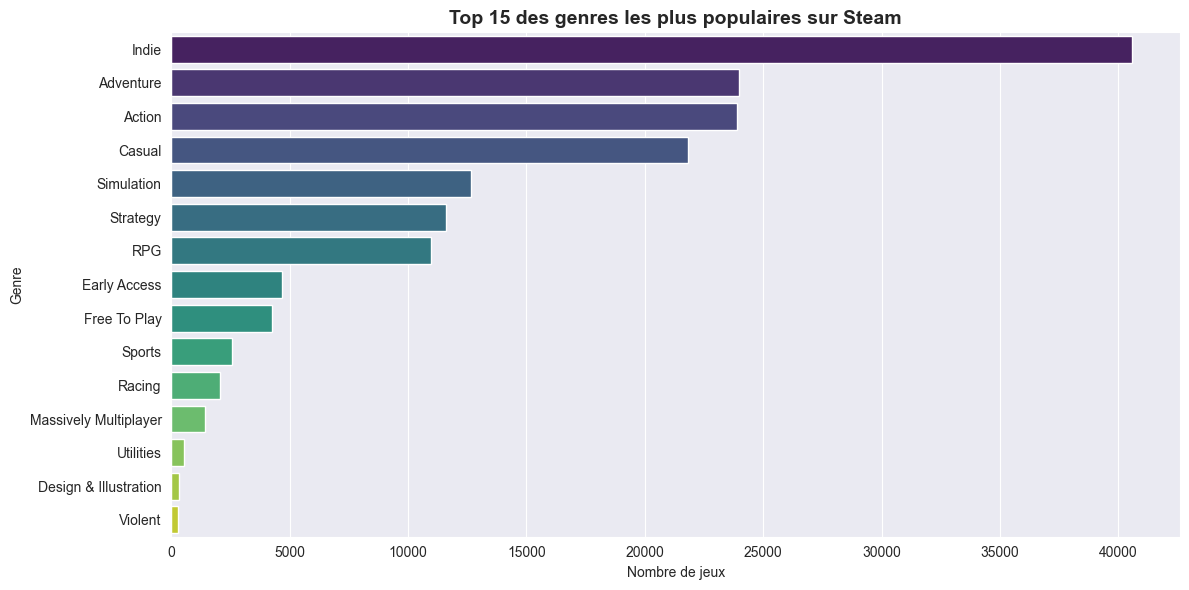

In [32]:
# Distribution des jeux payants : Lá on peut voir qu'il y a un pic énorme au tour de 50 dollars. 
# Gratuits vs payants : 53.4% des jeux sont gratuits, ce qui montre que les jeux free-to-play sont très populaires sur Steam et représentent une part importante de la bibliothèque de jeux.
# Distribution de la satisfaction : plutôt bonne, la majorité des jeux ont un taux de satisfaction entre 70% et 100%.
# Prix vs satisfaction: il n'y a pas de corrélation évidente, les jeux les plus chers ne sont pas forcément les mieux notés, et vice versa.


# La colonne Genres contient plusieurs genres séparés par des virgules
# Ex: "Action,Adventure,RPG", on va donc les séparer pour pouvoir analyser les genres individuellement
# D'abbord on explose la colonne en plusieurs lignes
df_genres = df_clean['Genres'].dropna().str.split(',').explode().str.strip()

# Top 15 des genres les plus populaires
top_genres = df_genres.value_counts().head(15)

# Graphique
plt.figure(figsize=(12,6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')
plt.title('Top 15 des genres les plus populaires sur Steam', fontsize=14, fontweight='bold')
plt.xlabel('Nombre de jeux')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

C:\Users\bruno\AppData\Local\Temp\ipykernel_36648\2344952380.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=satisfaction_par_genre['mean'],


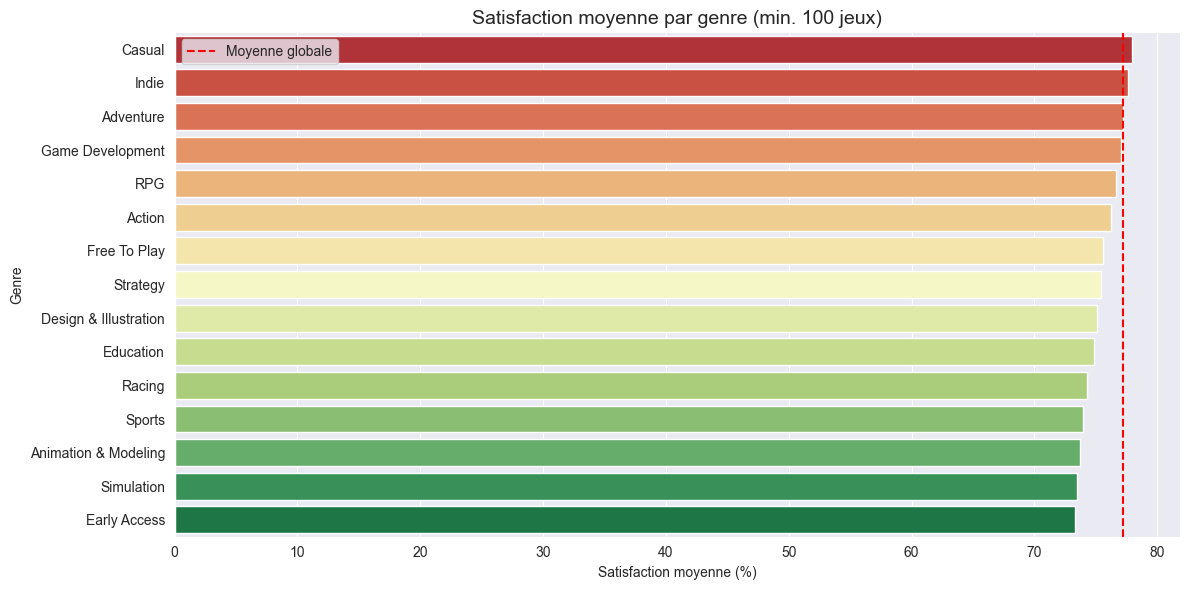

In [33]:
#Top 15 des genres les plus populaires : Indie domine Largement, ça s'explique car steam est une plateforme très accessible pour les petits développeurs, et il y a beaucoup de jeux indépendants qui sortent chaque année.

#Maitenant ce serait intéressant de voir si certains genres sont mieux notés que d'autres.

# On relie chaque genre à sa satisfaction
df_clean_copy = df_clean.copy()
df_clean_copy['Genres_split'] = df_clean_copy['Genres'].str.split(',')
df_exploded = df_clean_copy.explode('Genres_split')
df_exploded['Genres_split'] = df_exploded['Genres_split'].str.strip()

# Satisfaction moyenne par genre (garder genres avec au moins 100 jeux)
satisfaction_par_genre = (
    df_exploded.groupby('Genres_split')['satisfaction']
    .agg(['mean', 'count'])
    .query('count >= 100')
    .sort_values('mean', ascending=False)
    .head(15)
)

# Graphique
plt.figure(figsize=(12, 6))
sns.barplot(x=satisfaction_par_genre['mean'], 
            y=satisfaction_par_genre.index, 
            palette='RdYlGn')
plt.title('Satisfaction moyenne par genre (min. 100 jeux)', fontsize=14)
plt.xlabel('Satisfaction moyenne (%)')
plt.ylabel('Genre')
plt.axvline(x=df_clean['satisfaction'].mean(), 
            color='red', linestyle='--', label='Moyenne globale')
plt.legend()
plt.tight_layout()
plt.show()



In [34]:
# On va passer á SQL pour faire des analyses plus complexes et plus rapides, surtout pour les jointures entre les différentes tables (jeux, genres, développeurs, etc).

import sqlite3

# Créer une base de données SQLite locale (ça crée un fichier steam.db dans ton dossier)
conn = sqlite3.connect('steam.db')

# Charger notre dataframe nettoyé dans la base de données
df_clean.to_sql('games', conn, if_exists='replace', index=False)

print("Base de données créée avec succès !")
print(f"{len(df_clean)} jeux chargés dans la table 'games'")

Base de données créée avec succès !
56655 jeux chargés dans la table 'games'


In [35]:
def run_query(titre, query):
    print(f"\n{'='*60}")
    print(f"  {titre}")
    print(f"{'='*60}")
    result = panda.read_sql_query(query, conn)
    print(result.to_markdown(index=False))

# Requete pour trouver le prix moyen des jeux payants, ça nous permettra de voir combien les joueurs dépensent en moyenne pour un jeu sur steam
run_query("Prix moyen des jeux payants", """
    SELECT ROUND(AVG(Price), 2) AS prix_moyen
    FROM games
    WHERE Price > 0
""")

# Requete pour trouver les 10 jeux les plus populaires (en se basant sur le nombre d'avis positifs), ça nous permettra de voir quels sont les jeux les plus appréciés par la communauté
run_query("Top 10 jeux les plus populaires", """
    SELECT Name as Nom, Positive, Negative, Price
    FROM games
    ORDER BY Positive DESC
    LIMIT 10
""")

# Requete pour comparer les jeux gratuits et payants en termes de nombre de jeux et de satisfaction moyenne, ça nous permettra de voir si les jeux gratuits sont aussi populaires et bien notés que les jeux payants
run_query("Gratuits vs Payants", """
    SELECT 
        CASE WHEN Price = 0 THEN 'Gratuit' ELSE 'Payant' END AS Type,
        COUNT(*) AS Nombre_jeux,
        ROUND(AVG(satisfaction), 1) AS Satisfaction_moyenne
    FROM games
    GROUP BY Type
""")

# Requete pour trouver les jeux les mieux notés avec au moins 500 avis, ça nous permettra de voir quels sont les meilleurs jeux selon les joueurs
run_query("Top 10 jeux les mieux notés (min 500 avis)", """
    SELECT Name as Nom, ROUND(satisfaction, 1) as Satisfaction, 
           Positive, Negative, Price
    FROM games
    WHERE (Positive + Negative) >= 500
    ORDER BY satisfaction DESC
    LIMIT 10
""")

# Requete pour trouver le prix moyen par tranche de satisfaction, ça nous permettra de voir si les jeux les mieux notés sont aussi les plus chers
run_query("Prix moyen par tranche de satisfaction", """
    SELECT 
        CASE 
            WHEN satisfaction >= 90 THEN '90-100% (Très positif)'
            WHEN satisfaction >= 70 THEN '70-90% (Positif)'
            WHEN satisfaction >= 50 THEN '50-70% (Mitigé)'
            ELSE 'Moins de 50% (Négatif)'
        END AS tranche,
        COUNT(*) AS nombre_jeux,
        ROUND(AVG(Price), 2) AS prix_moyen
    FROM games
    GROUP BY tranche
    ORDER BY prix_moyen DESC
""")

# Requete pour trouver les développeurs avec le plus de jeux sur steam, ça nous permettra de voir quels sont les studios les plus prolifiques sur la plateforme
run_query("Top 10 développeurs avec le plus de jeux", """
    SELECT Developers AS Developpeur, 
           COUNT(*) AS nombre_jeux,
           ROUND(AVG(satisfaction), 1) AS satisfaction_moyenne,
           ROUND(AVG(Price), 2) AS prix_moyen
    FROM games
    WHERE Developers != ''
    GROUP BY Developers
    ORDER BY nombre_jeux DESC
    LIMIT 10
""")
# Requete pour trouver les jeux gratuits les mieux notés avec au moins 1000 avis, ça nous permettra de voir quels sont les meilleurs jeux gratuits sur steam
run_query("Jeux gratuits les mieux notés (min 1000 avis)", """
    SELECT Name AS Nom, 
           ROUND(satisfaction, 1) AS Satisfaction,
           Positive,
           Negative
    FROM games
    WHERE Price = 0
    AND (Positive + Negative) >= 1000
    ORDER BY satisfaction DESC
    LIMIT 10
""")


  Prix moyen des jeux payants
|   prix_moyen |
|-------------:|
|        59.21 |

  Top 10 jeux les plus populaires
| Nom                               |   Positive |   Negative |   Price |
|:----------------------------------|-----------:|-----------:|--------:|
| Counter-Strike 2                  |    7642084 |    1173003 |       0 |
| Dota 2                            |    2037143 |     461826 |       0 |
| Grand Theft Auto V Legacy         |    1739980 |     250576 |       0 |
| PUBG: BATTLEGROUNDS               |    1520457 |    1037487 |       0 |
| Terraria                          |    1373979 |      35494 |      50 |
| Tom Clancy's Rainbow Six® Siege X |    1172854 |     225730 |       0 |
| Garry's Mod                       |    1122546 |      37161 |      50 |
| Black Myth: Wukong                |    1111720 |      38378 |       0 |
| Rust                              |    1071135 |     156649 |      50 |
| Team Fortress 2                   |    1044264 |     117208 |      

In [38]:
# Exporter le dataset nettoyé
df_clean.to_csv('steam_clean.csv', index=False)
print("Fichier exporté avec succès !")

Fichier exporté avec succès !
